In [2]:
import cv2

In [3]:
cv2.__version__

'4.13.0'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.tensorboard import SummaryWriter

In [5]:
os.makedirs(os.path.join(os.getcwd(), 'Ex12', 'data'), exist_ok = True)
data_dir = os.path.join(os.getcwd(), 'Ex12', 'data')

In [6]:
train_data = datasets.MNIST(root = data_dir, train = True, download = True)
test_data = datasets.MNIST(root = data_dir, train = False)

In [7]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [8]:
train_data[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [9]:
train_data.data # trả về dữ liệu thô dưới dạng tensor

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [10]:
train_data.data.requires_grad

False

In [11]:
train_data.data[0]  # chưa được chuẩn hóa

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [12]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [13]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [14]:
X_train, y_train = train_data.data.numpy(), train_data.targets.numpy()
X_test, y_test = test_data.data.numpy(), test_data.targets.numpy()

In [15]:
X_train.shape

(60000, 28, 28)

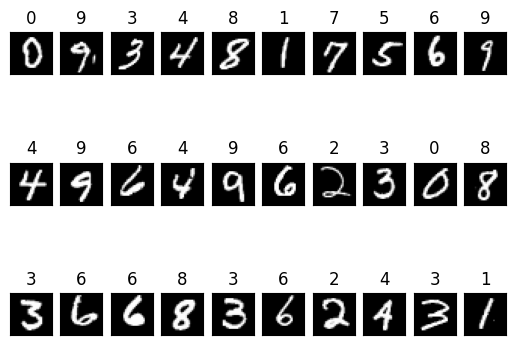

In [16]:
for i in range(30):
    id = np.random.randint(X_train.shape[0])
    plt.subplot(3,10,i+1)
    plt.imshow(X_train[id], cmap = 'gray')
    plt.title(f'{y_train[id]}')
    plt.xticks([])
    plt.yticks([])

In [17]:
X_train, X_test = X_train/255, X_test/255
X_train, X_test = (X_train - X_train.mean())/X_train.std(), (X_test - X_test.mean())/X_test.std()

In [18]:
(train_data.data.to(torch.float64)/255).mean(), (train_data.data.to(torch.float64)/255).std()

(tensor(0.1307, dtype=torch.float64), tensor(0.3081, dtype=torch.float64))

In [19]:
X_train.shape

(60000, 28, 28)

In [20]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2])

In [21]:
X_train.shape, X_test.shape

((60000, 1, 28, 28), (10000, 1, 28, 28))

Dilation: phóng to kernel nhưng giữ nguyên số phần tử của kernel 
* 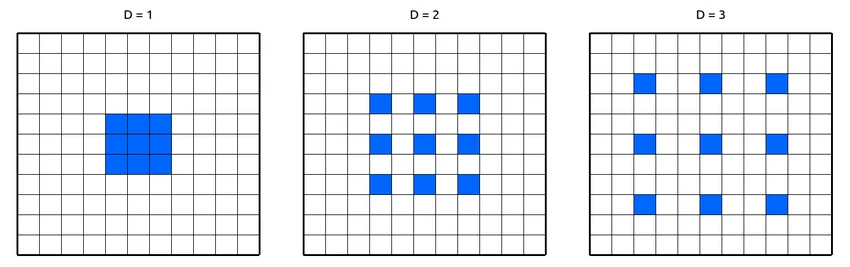

In [22]:
class BasicCnn(nn.Module):
    def __init__(self, dropout_rate):
        super(BasicCnn, self).__init__()
        # tham số đầu vào stride có thể là 1 tuple vì có thể stride của các chiều có thể khác nhau
        # bias dùng để cộng thê vào kết quả của phép tích chập 1 đại lượng bias
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, stride = (1,1), padding = 0, bias = False, dilation = 1)
        self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = (1,1), padding = 0, bias = False, dilation = 1)
        self.dropout = nn.Dropout(dropout_rate)
        self.maxpool = nn.AdaptiveMaxPool2d((12,12))
        self.dense1 = nn.Linear(12*12*64, 512)
        self.dense2 = nn.Linear(512, 10)
    def forward(self, X):
        X = self.conv1(X)
        X = self.conv2(X)
        X = self.maxpool(X)
        X = torch.flatten(X, start_dim = 1, end_dim = -1)
        X = self.dense1(X)
        X = self.dropout(X)
        X = self.dense2(X)
        return X

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [24]:
simple_model = BasicCnn(dropout_rate = 0.5).cuda() # giống to(device)

In [25]:
for param in simple_model.parameters():
    print(param)

Parameter containing:
tensor([[[[-9.0894e-02, -1.5167e-01, -9.3821e-02],
          [-2.0974e-01,  2.1271e-01,  2.2183e-01],
          [ 8.4428e-02,  1.3514e-01, -7.4378e-02]]],


        [[[-6.4217e-02,  1.7785e-01, -1.9118e-01],
          [ 1.8518e-01, -7.5618e-02,  1.9996e-01],
          [-3.0905e-01, -2.5570e-01,  2.5268e-01]]],


        [[[-2.8566e-01,  7.5594e-02, -9.5021e-02],
          [-3.2099e-01,  7.9964e-03,  2.5041e-01],
          [ 1.5222e-01,  1.7363e-01, -1.7383e-01]]],


        [[[-2.6309e-01,  3.6786e-02, -3.2178e-01],
          [ 2.1309e-01,  3.2335e-01,  2.3192e-01],
          [ 5.2098e-02,  2.9929e-01,  1.2859e-01]]],


        [[[-3.2496e-01,  2.8167e-01,  3.2749e-01],
          [-1.7233e-01,  1.0409e-01, -2.4207e-01],
          [ 6.4032e-02, -4.1554e-02,  2.5357e-02]]],


        [[[ 2.4320e-01, -1.6093e-01, -3.1251e-02],
          [ 5.1924e-02, -2.8232e-01,  2.2189e-01],
          [ 2.3780e-01, -2.2283e-01, -3.1792e-01]]],


        [[[-1.1883e-01,  4.7492e-02,

In [26]:
rand_input = torch.rand(2,1,28,28).cuda()
output = simple_model(rand_input)
output.shape

torch.Size([2, 10])

In [27]:
model_parameters = filter(lambda p: p.requires_grad, simple_model.parameters())
param_count = 0
for p in model_parameters:
    param_count += p.numel()
print(f'numer of parameter: {param_count}')

numer of parameter: 4742954


In [28]:
class Generator(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return self.images.shape[0]
    def __getitem__(self, id):
        return self.images[id], self.labels[id]

In [29]:
training_data = Generator(X_train, y_train)
train_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)
len(training_data), len(train_dataloader)

(60000, 1875)

len(dataloader) = ceil(len(data)/batch_size)

In [30]:
test_data = Generator(X_test, y_test)
test_dataloader = DataLoader(test_data, batch_size = 32, shuffle = True)
len(test_data), len(test_dataloader)

(10000, 313)

# Dropout test

In [31]:
# drop rate 0
best_loss = float('inf')
model_dropout0 = BasicCnn(dropout_rate = 0)
optimizer = torch.optim.Adam(model_dropout0.parameters(), lr = 1e-3)


In [32]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [33]:
model_dropout0 = model_dropout0.to(torch.device('cuda'))

In [34]:
optimizer.param_groups

[{'params': [Parameter containing:
   tensor([[[[-5.2630e-02,  3.6116e-02,  2.7185e-01],
             [ 1.2649e-01,  2.2861e-01, -1.0777e-01],
             [-1.2700e-01,  1.6223e-01, -9.7523e-02]]],
   
   
           [[[-1.0840e-01,  3.0292e-01, -2.1920e-01],
             [ 1.7552e-01, -4.0751e-02, -9.9790e-02],
             [ 3.2952e-01,  2.6495e-01,  1.7826e-01]]],
   
   
           [[[ 3.0332e-01, -5.9943e-02,  2.3482e-01],
             [ 6.8177e-02,  2.2476e-01, -1.5958e-01],
             [ 1.9487e-01, -1.1972e-01, -1.6654e-01]]],
   
   
           [[[ 5.5367e-02, -9.9364e-02,  2.5666e-01],
             [ 3.0425e-01,  1.3162e-01,  1.9979e-01],
             [ 2.7076e-01, -1.7133e-01,  6.4045e-02]]],
   
   
           [[[-9.9577e-02,  1.3443e-01,  9.4867e-02],
             [-2.0490e-01, -1.3398e-01,  6.6671e-02],
             [ 3.1799e-01,  1.0906e-01, -4.6616e-02]]],
   
   
           [[[-4.4777e-03,  1.2069e-01,  3.2962e-01],
             [ 2.9409e-02,  2.6033e-01, -2.0561e-01

thuộc tính param_group của optimizer trả về 1 list 1 phần tử với phần tử là 1 dict

In [35]:
def train(model, epoch, writer, optimizer):
    print(f'\n ############################# Train phase, Epoch: {epoch} #############################')
    model.train()
    train_loss = 0
    running_loss = 0 # trung bình cộng loss của các batch trong 1 epoch
    print(f'\n Learning rate at this epoch is: {optimizer.param_groups[0]['lr']}')
    for (batch_id, target_tuple) in enumerate(train_dataloader):
        images, labels = target_tuple[0].to(device).float(), target_tuple[1].to(device)
        labels = torch.tensor(labels, dtype = torch.long)
        optimizer.zero_grad()
        output = model(images)
        loss = F.cross_entropy(output, labels).to(device)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*images.shape[0]
        running_loss += loss.item()
        # epoch được bắt đầu từ 0, tính trung bình loss của 50 epoch một
        if batch_id % 50 == 49:
            writer.add_scalar('training loss', running_loss/50, epoch * len(train_dataloader) + batch_id)
            # tham số đầu tiên là tên biểu đồ, tham số thứ 2 là trục y thứ 3 là trục x
            running_loss = 0
    train_loss/=len(train_dataloader.dataset)
    print(f'Train loss: {train_loss}')

In [36]:
def test(model, epoch, writer):
    print(f'\n ############################# Test phase, Epoch: {epoch} #############################')
    model.eval()
    with torch.no_grad():
        test_loss = 0
        correct = 0
        for (batch_id, target_tuple) in enumerate(test_dataloader):
            images, labels = target_tuple[0].to(device).float(), target_tuple[1].to(device)
            labels = torch.tensor(labels, dtype = torch.long)
            output = model(images)
            predict = output.argmax(dim = 1)
            correct += predict.eq(labels.view_as(predict)).sum().item()
            loss = F.cross_entropy(output, labels)
            test_loss += loss.item()
        acc = correct*100/len(test_dataloader.dataset) 
        print(f'Accuracy: {acc}')
        writer.add_scalar('test accuracy', acc, epoch)

In [37]:
def train_and_test(model, optimizer, summary_path, epoch_num = 5):
    writer = SummaryWriter(summary_path)
    for epoch in range(epoch_num):
        train(model, epoch, writer, optimizer)
        test(model, epoch, writer)

In [38]:
os.makedirs(os.path.join(os.getcwd(), 'Ex12', 'runs'), exist_ok = True)
summary_path = os.path.join(os.getcwd(), 'Ex12', 'runs', 'mnist_experiment_dropout0')

# CHÚ Ý
* Dataloader có thể tự chuyển array về tensor nhưng định dạng sẽ là torch.float64 hay double
* Trọng số của model ban đầu là float32 hay float, phải ép kiểu của input thành float thì mới không xảy ra lỗi

In [39]:
train_and_test(model = model_dropout0, optimizer = optimizer, summary_path = summary_path)


 ############################# Train phase, Epoch: 0 #############################

 Learning rate at this epoch is: 0.001


C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_13096\818468499.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype = torch.long)


Train loss: 0.21368126007420943

 ############################# Test phase, Epoch: 0 #############################
Accuracy: 96.22

 ############################# Train phase, Epoch: 1 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.12796891130690152

 ############################# Test phase, Epoch: 1 #############################
Accuracy: 96.07

 ############################# Train phase, Epoch: 2 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.1111792876246851

 ############################# Test phase, Epoch: 2 #############################
Accuracy: 96.89

 ############################# Train phase, Epoch: 3 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.09836060279959347

 ############################# Test phase, Epoch: 3 #############################
Accuracy: 95.93

 ############################# Train phase, Epoch: 4 #############################

 Learning rate at th

KeyboardInterrupt: 

In [ ]:
#%tensorboard --logdir Ex12/runs/mnist_experiment_dropout0

In [40]:
summary_path05 = os.path.join(os.getcwd(), 'Ex12', 'runs', 'mnist_experiment_dropout0.5')
model_dropout05 = BasicCnn(dropout_rate = 0.5)
optimizer05 = torch.optim.Adam(model_dropout05.parameters(), lr = 1e-3)
model_dropout05.to(device)
train_and_test(model = model_dropout05, optimizer = optimizer05, summary_path = summary_path05)


 ############################# Train phase, Epoch: 0 #############################

 Learning rate at this epoch is: 0.001


C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_13096\818468499.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype = torch.long)


KeyboardInterrupt: 

In [47]:
class SimpleModel(nn.Module):
    def __init__(self, dropout_rate = 0.5, activation = None):
        super(SimpleModel, self).__init__()
        self.dense_1 = nn.Linear(28*28, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.dense_2 = nn.Linear(512,10)
        self.activation = activation
    def forward(self, X):
        X = torch.flatten(X, start_dim = 1, end_dim = -1)
        X = self.dense_1(X)
        if self.activation != None:
            X = self.activation(X)
        X = self.dropout(X)
        X = self.dense_2(X)
        return X

In [48]:
rand_input = torch.rand(3,1,28,28).cuda()
simple_model = SimpleModel(activation = nn.ReLU()).cuda()
output_test = simple_model(rand_input)
output_test.shape

torch.Size([3, 10])

In [49]:
model_parameters = filter(lambda p: p.requires_grad, simple_model.parameters())
param_count = 0
for p in model_parameters:
    param_count += p.numel()
print(f'numer of parameter: {param_count}')

numer of parameter: 407050


In [50]:
# nếu không sử dụng hàm kích hoạt
summary_dir = os.path.join(os.getcwd(), 'Ex12', 'runs', 'mnist_no_activation')
model_no_activate = SimpleModel(activation = None).cuda()
optimizer = torch.optim.Adam(model_no_activate.parameters(), lr = 1e-3)
train_and_test(model = model_no_activate, optimizer = optimizer, summary_path = summary_dir)


 ############################# Train phase, Epoch: 0 #############################

 Learning rate at this epoch is: 0.001


C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_13096\818468499.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype = torch.long)


Train loss: 0.4736912869334221

 ############################# Test phase, Epoch: 0 #############################
Accuracy: 90.72

 ############################# Train phase, Epoch: 1 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.4472260119001071

 ############################# Test phase, Epoch: 1 #############################
Accuracy: 89.71

 ############################# Train phase, Epoch: 2 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.44688619817396

 ############################# Test phase, Epoch: 2 #############################
Accuracy: 90.35

 ############################# Train phase, Epoch: 3 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.4425298162092765

 ############################# Test phase, Epoch: 3 #############################
Accuracy: 90.79

 ############################# Train phase, Epoch: 4 #############################

 Learning rate at this ep

In [53]:
for activation in [nn.ReLU(), nn.Tanh(), nn.Sigmoid()]:
    summary_path = os.path.join(os.getcwd(), 'Ex12', 'runs', f'mnist_with_activation_{activation}')
    model = SimpleModel(dropout_rate = 0.5, activation = activation).cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
    print(str(activation))
    train_and_test(model = model, optimizer = optimizer, summary_path = summary_path)

ReLU()

 ############################# Train phase, Epoch: 0 #############################

 Learning rate at this epoch is: 0.001


C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_13096\818468499.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype = torch.long)


Train loss: 0.2736030157690247

 ############################# Test phase, Epoch: 0 #############################
Accuracy: 95.32

 ############################# Train phase, Epoch: 1 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.164229568426311

 ############################# Test phase, Epoch: 1 #############################
Accuracy: 97.02

 ############################# Train phase, Epoch: 2 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.14018144423044288

 ############################# Test phase, Epoch: 2 #############################
Accuracy: 97.46

 ############################# Train phase, Epoch: 3 #############################

 Learning rate at this epoch is: 0.001
Train loss: 0.12925569588697206

 ############################# Test phase, Epoch: 3 #############################
Accuracy: 97.69

 ############################# Train phase, Epoch: 4 #############################

 Learning rate at this

# Learning Rate Test

In [57]:
learning_rates = [1E-0, 1E-1, 1E-2, 1E-3, 1E-4, 1E-5, 1E-6, 1E-7]
for lr in learning_rates:
    summary_path = os.path.join(os.getcwd(), 'Ex12', 'runs', f'mnist_with_lr_{lr}')
    model = SimpleModel(dropout_rate = 0.5, activation = nn.ReLU()).cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    print(f'Learning rate = {lr}\n')
    train_and_test(model = model, optimizer = optimizer, summary_path = summary_path)

Learning rate = 1.0


 ############################# Train phase, Epoch: 0 #############################

 Learning rate at this epoch is: 1.0


C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_13096\818468499.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype = torch.long)


Train loss: 103.46290254573822

 ############################# Test phase, Epoch: 0 #############################
Accuracy: 9.79

 ############################# Train phase, Epoch: 1 #############################

 Learning rate at this epoch is: 1.0
Train loss: 7.172838644536336

 ############################# Test phase, Epoch: 1 #############################
Accuracy: 10.15

 ############################# Train phase, Epoch: 2 #############################

 Learning rate at this epoch is: 1.0
Train loss: 3.5912520904541014

 ############################# Test phase, Epoch: 2 #############################
Accuracy: 9.91

 ############################# Train phase, Epoch: 3 #############################

 Learning rate at this epoch is: 1.0
Train loss: 4.277023269780477

 ############################# Test phase, Epoch: 3 #############################
Accuracy: 11.45

 ############################# Train phase, Epoch: 4 #############################

 Learning rate at this epoch is: 

# Giảm lr theo exponentialLR
* lr = lr * gamma^epoch

In [59]:
def train(model, epoch, writer, optimizer, scheduler):
    print(f'\n ############################# Train phase, Epoch: {epoch} #############################')
    model.train()
    train_loss = 0
    running_loss = 0 # trung bình cộng loss của các batch trong 1 epoch
    print(f'\n Learning rate at this epoch is: {scheduler.get_last_lr()}')
    for (batch_id, target_tuple) in enumerate(train_dataloader):
        images, labels = target_tuple[0].to(device).float(), target_tuple[1].to(device)
        labels = torch.tensor(labels, dtype = torch.long)
        optimizer.zero_grad()
        output = model(images)
        loss = F.cross_entropy(output, labels).to(device)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*images.shape[0]
        running_loss += loss.item()
        # epoch được bắt đầu từ 0, tính trung bình loss của 50 epoch một
        if batch_id % 50 == 49:
            writer.add_scalar('training loss', running_loss/50, epoch * len(train_dataloader) + batch_id)
            # tham số đầu tiên là tên biểu đồ, tham số thứ 2 là trục y thứ 3 là trục x
            running_loss = 0
    train_loss/=len(train_dataloader.dataset)
    print(f'Train loss: {train_loss}')

In [62]:
def train_and_test(model, optimizer, summary_path, scheduler, epoch_num = 5):
    writer = SummaryWriter(summary_path)
    for epoch in range(epoch_num):
        train(model, epoch, writer, optimizer, scheduler)
        test(model, epoch, writer)
        scheduler.step()

In [66]:
summary_path = os.path.join(os.getcwd(), 'Ex12', 'runs', 'exponentialLR')
model = SimpleModel(dropout_rate = 0.5, activation = nn.ReLU()).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.9)
train_and_test(model = model, optimizer = optimizer, summary_path = summary_path, scheduler = scheduler, epoch_num = 20)



 ############################# Train phase, Epoch: 0 #############################

 Learning rate at this epoch is: [0.01]


C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_13096\3946627347.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype = torch.long)


Train loss: 0.7838148108998935

 ############################# Test phase, Epoch: 0 #############################
Accuracy: 88.26

 ############################# Train phase, Epoch: 1 #############################

 Learning rate at this epoch is: [0.009000000000000001]
Train loss: 0.6901341468950113

 ############################# Test phase, Epoch: 1 #############################
Accuracy: 91.31

 ############################# Train phase, Epoch: 2 #############################

 Learning rate at this epoch is: [0.008100000000000001]
Train loss: 0.6337056553781033

 ############################# Test phase, Epoch: 2 #############################
Accuracy: 92.13

 ############################# Train phase, Epoch: 3 #############################

 Learning rate at this epoch is: [0.007290000000000001]
Train loss: 0.5829835295438767

 ############################# Test phase, Epoch: 3 #############################
Accuracy: 92.12

 ############################# Train phase, Epoch: 4 ###